# Online Retail Dataset

## Context
You can find it at https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci.

This Online Retail II data set contains all the transactions occurring for a UK-based and registered, non-store online retail between 01/12/2009 and 09/12/2011.The company mainly sells unique all-occasion gift-ware. Many customers of the company are wholesalers.

## Column information
- InvoiceNo: Invoice number. Nominal. A 6-digit integral number uniquely assigned to each transaction. If this code starts with the letter 'c', it indicates a cancellation.
- StockCode: Product (item) code. Nominal. A 5-digit integral number uniquely assigned to each distinct product.
- Description: Product (item) name. Nominal.
- Quantity: The quantities of each product (item) per transaction. Numeric.
- InvoiceDate: Invice date and time. Numeric. The day and time when a transaction was generated.
- UnitPrice: Unit price. Numeric. Product price per unit in sterling (Â£).
- CustomerID: Customer number. Nominal. A 5-digit integral number uniquely assigned to each customer.
- Country: Country name. Nominal. The name of the country where a customer resides.

# Step 2 Response:
I put most of my thought into understanding the business sequence and how best to align the churn label with the data that would be used to train and then predict it. I decided that the churn was actually a behavior from next month that needed to be projected onto the data from this month. With historical data you can do this. For current data, that's the meat of the model - predict what is going to happen NEXT month!

My primary research would be to sit down with the business and work with them to agree on what constitutes churn. As I discuss below at length, this wasn't entirely clear from the instructions. I would also want a better picture of who is a customer. Perhaps we could better identify the set of concern - multiple purchases, lives in a certain area, overall tenure etc.

I expect that the best features for prediction would be date based - how long have they been a customer, how long since the last purchase, number of transactions per month etc. We could also try to model each individual customer's behavior and then try to detect changes in that behavior.

# Understanding the data

In [131]:
import pandas as pd
import numpy as np

In [132]:
from google.colab import drive
drive.mount('/content/drive')

original_df = pd.read_csv('/content/drive/MyDrive/newman_data_preprocessing/Online Retail II/online_retail_II.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [133]:
print("Shape:", original_df.shape)
print("\nColumn names:\n", original_df.columns.tolist())
print("\nData types:\n", original_df.dtypes)
original_df.head(5)

Shape: (1067371, 8)

Column names:
 ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

Data types:
 Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
dtype: object


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [134]:
original_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


## First Thoughts about this data...
- Why are some customer IDs null? Should we remove them?
- Should we include cancellations?
- Why is invoice date not a date column?
- Why price and quantity column, but no revenue column? Revenue = price * quantity
- There are multiple items on the same invoice --> one row per product per invoice
- Should we group by invoice to avoid repetition on Invoice ID and InvoiceDate?

## Questiont that we are asked:
- What customers did not buy anything in the last month worth of data?
- Can we predict what happens next month?

# Coding

## Basic Cleaning

### Remove null customers

In [135]:
print("Missing values:\n", original_df.isnull().sum())
print("\nRows before cleaning:", len(original_df))

Missing values:
 Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Rows before cleaning: 1067371


In [136]:
df = original_df.dropna(subset=['Customer ID']) #drop na on the column that we do not want null values
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


### Remove cancellations

In [137]:
df[df['Invoice'].astype(str).str.startswith('C')]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
...,...,...,...,...,...,...,...,...
1065910,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
1067002,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
1067176,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
1067177,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


In [138]:
df = df[~df['Invoice'].astype(str).str.startswith('C')]

In [139]:
print(f"Rows after cleaning: {len(df)}")

Rows after cleaning: 805620


### Format dates column

In [140]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

/tmp/ipykernel_4776/3633860036.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


### Add revenue column

In [141]:
df['Revenue'] = df['Quantity'] * df['Price']

/tmp/ipykernel_4776/2072779206.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Revenue'] = df['Quantity'] * df['Price']


### Make Customer ID int

In [142]:
# JSP 20260414
df['Customer ID'] = df['Customer ID'].astype(int)

/tmp/ipykernel_4776/457032021.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Customer ID'] = df['Customer ID'].astype(int)


## EDA
EDA is not separate from feature engineering — it MOTIVATES it.

### Is there (still) any negative quantity or price?

In [143]:
import matplotlib.pyplot as plt

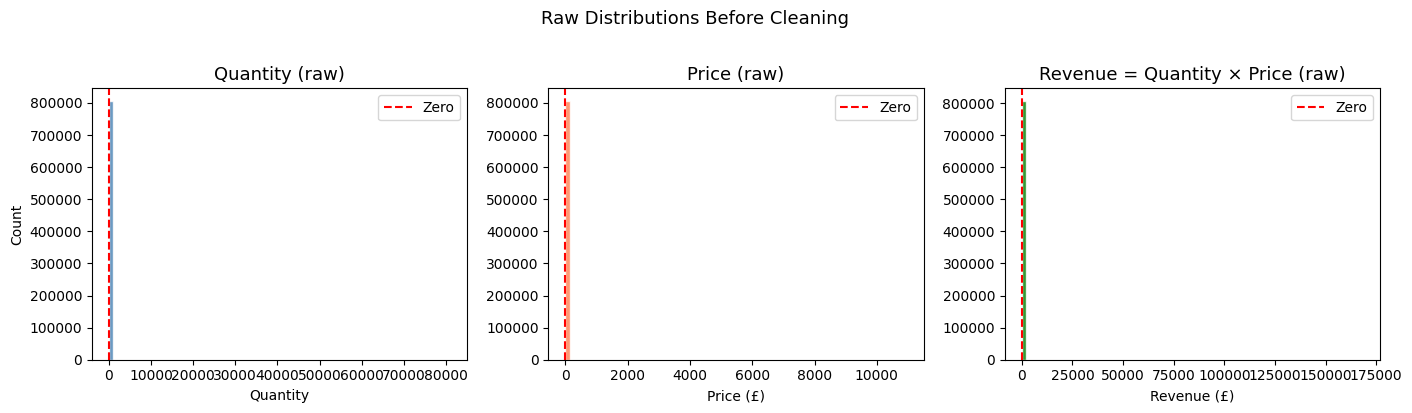

In [144]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(df['Quantity'], bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero')
axes[0].set_title('Quantity (raw)', fontsize=13)
axes[0].set_xlabel('Quantity')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(df['Price'], bins=80, color='coral', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero')
axes[1].set_title('Price (raw)', fontsize=13)
axes[1].set_xlabel('Price (£)')
axes[1].legend()

axes[2].hist((df['Revenue']), bins=80, color='green',
             edgecolor='white', alpha=0.8)
axes[2].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero')
axes[2].set_title('Revenue = Quantity × Price (raw)', fontsize=13)
axes[2].set_xlabel('Revenue (£)')
axes[2].legend()

plt.suptitle('Raw Distributions Before Cleaning',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [145]:
df['Quantity']

,Quantity
0,12
1,12
2,12
3,48
4,24
...,...
1067366,6
1067367,4
1067368,4
1067369,3


In [146]:
[df['Quantity'] < 1000]

[0          True
 1          True
 2          True
 3          True
 4          True
            ... 
 1067366    True
 1067367    True
 1067368    True
 1067369    True
 1067370    True
 Name: Quantity, Length: 805620, dtype: bool]

In [147]:
df['Quantity'][df['Quantity'] < 1000]

,Quantity
0,12
1,12
2,12
3,48
4,24
...,...
1067366,6
1067367,4
1067368,4
1067369,3


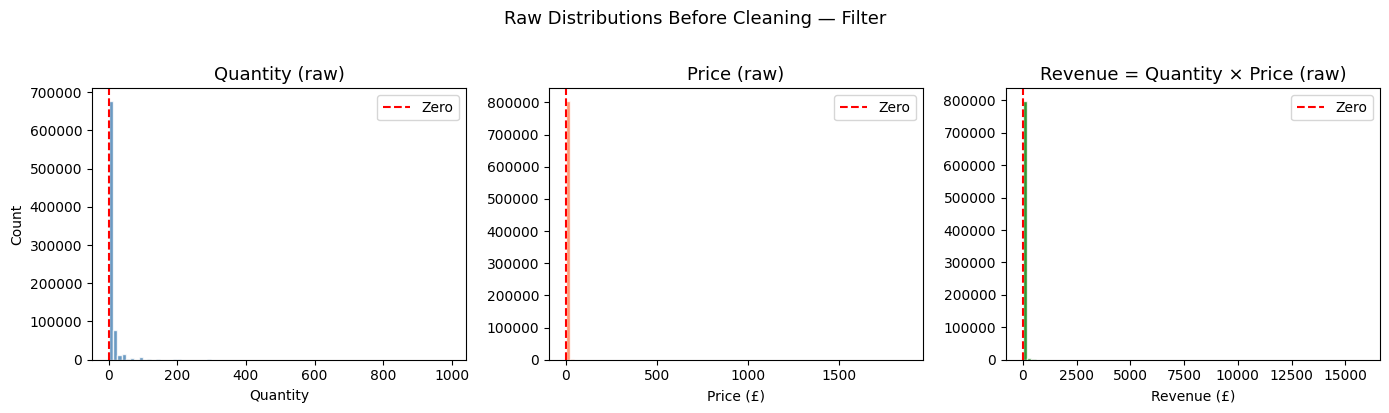

In [148]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(df['Quantity'][df['Quantity'] < 1000], bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero')
axes[0].set_title('Quantity (raw)', fontsize=13)
axes[0].set_xlabel('Quantity')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(df['Price'][df['Price'] < 2000], bins=80, color='coral', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero')
axes[1].set_title('Price (raw)', fontsize=13)
axes[1].set_xlabel('Price (£)')
axes[1].legend()

axes[2].hist((df['Revenue'][df['Revenue'] < 25000]), bins=80, color='green',
             edgecolor='white', alpha=0.8)
axes[2].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero')
axes[2].set_title('Revenue = Quantity × Price (raw)', fontsize=13)
axes[2].set_xlabel('Revenue (£)')
axes[2].legend()

plt.suptitle('Raw Distributions Before Cleaning — Filter',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

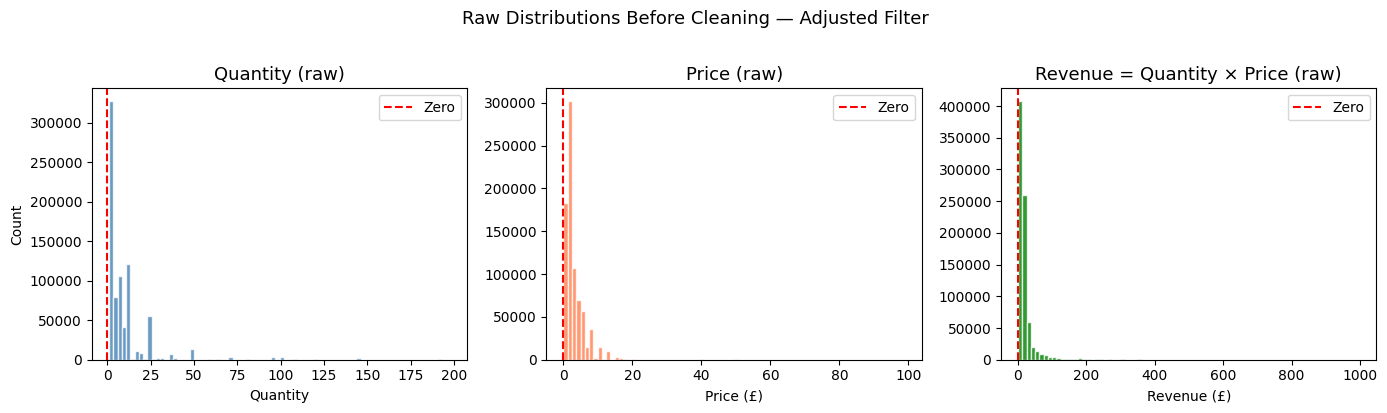

In [149]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(df['Quantity'][df['Quantity'] < 200], bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero')
axes[0].set_title('Quantity (raw)', fontsize=13)
axes[0].set_xlabel('Quantity')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(df['Price'][df['Price'] < 100], bins=80, color='coral', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero')
axes[1].set_title('Price (raw)', fontsize=13)
axes[1].set_xlabel('Price (£)')
axes[1].legend()

axes[2].hist((df['Revenue'][df['Revenue'] < 1000]), bins=80, color='green',
             edgecolor='white', alpha=0.8)
axes[2].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero')
axes[2].set_title('Revenue = Quantity × Price (raw)', fontsize=13)
axes[2].set_xlabel('Revenue (£)')
axes[2].legend()

plt.suptitle('Raw Distributions Before Cleaning — Adjusted Filter',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Group by invoice

In [150]:
df.head(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


In [151]:
df[df.Invoice == 489434]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue


In [152]:
df[df.Invoice == '489434']

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085,United Kingdom,39.6
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085,United Kingdom,59.5


In [153]:
invoice_df = df.groupby(['Invoice', 'Customer ID', 'Country', 'InvoiceDate']).agg(
    total_quantity = ('Quantity', 'sum'),
    total_revenue  = ('Revenue', 'sum'),
    num_items      = ('StockCode', 'nunique')   # how many distinct products per invoice
).reset_index()

invoice_df

,Invoice,Customer ID,Country,InvoiceDate,total_quantity,total_revenue,num_items
0,489434,13085,United Kingdom,2009-12-01 07:45:00,166,505.30,8
1,489435,13085,United Kingdom,2009-12-01 07:46:00,60,145.80,4
2,489436,13078,United Kingdom,2009-12-01 09:06:00,193,630.33,19
3,489437,15362,United Kingdom,2009-12-01 09:08:00,145,310.75,23
4,489438,18102,United Kingdom,2009-12-01 09:24:00,826,2286.24,17
...,...,...,...,...,...,...,...
37034,581583,13777,United Kingdom,2011-12-09 12:23:00,76,124.60,2
37035,581584,13777,United Kingdom,2011-12-09 12:25:00,120,140.64,2
37036,581585,15804,United Kingdom,2011-12-09 12:31:00,278,329.05,21
37037,581586,13113,United Kingdom,2011-12-09 12:49:00,66,339.20,4


### Transactions (and invoices) time series analysis

#### Daily

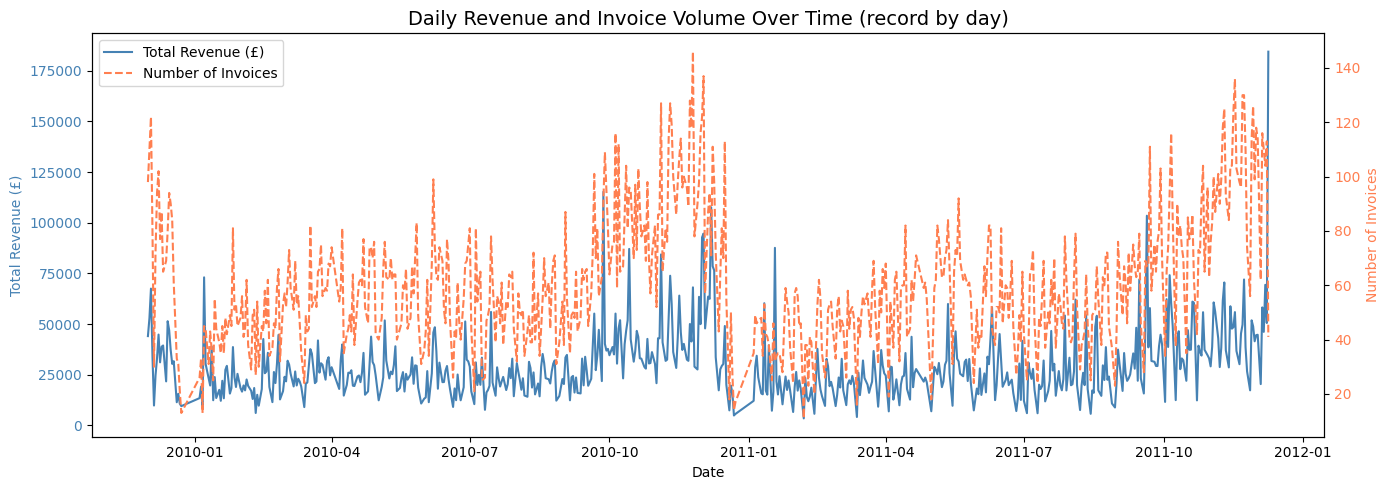

In [154]:
daily = invoice_df.groupby(invoice_df['InvoiceDate'].dt.date).agg(
    total_revenue  = ('total_revenue', 'sum'),
    num_invoices   = ('Invoice', 'count')
).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 5))

# Revenue line — left axis
ax1.plot(daily['InvoiceDate'], daily['total_revenue'],
         color='steelblue', linewidth=1.5, label='Total Revenue (£)')
ax1.set_xlabel('Date')
ax1.set_ylabel('Total Revenue (£)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Number of invoices — right axis
ax2 = ax1.twinx()
ax2.plot(daily['InvoiceDate'], daily['num_invoices'],
         color='coral', linewidth=1.5, linestyle='--', label='Number of Invoices')
ax2.set_ylabel('Number of Invoices', color='coral')
ax2.tick_params(axis='y', labelcolor='coral')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.set_title('Daily Revenue and Invoice Volume Over Time (record by day)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [155]:
### Helper function
def plot_revenue_invoices(data, x_col, title, xlabel, figsize=(14, 4), skip = False):
    fig, ax1 = plt.subplots(figsize=figsize)

    ax1.plot(data[x_col], data['total_revenue'],
             color='steelblue', linewidth=1.5, label='Total Revenue (£)')
    ax1.set_xlabel(xlabel)
    ax1.set_ylabel('Total Revenue (£)', color='steelblue')
    ax1.tick_params(axis='y', labelcolor='steelblue')

    ax2 = ax1.twinx()
    ax2.plot(data[x_col], data['num_invoices'],
             color='coral', linewidth=1.5, linestyle='--', label='Number of Invoices')
    ax2.set_ylabel('Number of Invoices', color='coral')
    ax2.tick_params(axis='y', labelcolor='coral')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    ax1.set_title(title, fontsize=13)
    # Handle x-ticks
    if skip:
        ticks = range(0, len(data), 2)
        ax1.set_xticks(ticks)
        ax1.set_xticklabels(data[x_col].iloc[ticks], rotation=45, ha='right')
    else:
        ax1.set_xticks(range(len(data)))
        ax1.set_xticklabels(data[x_col], rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

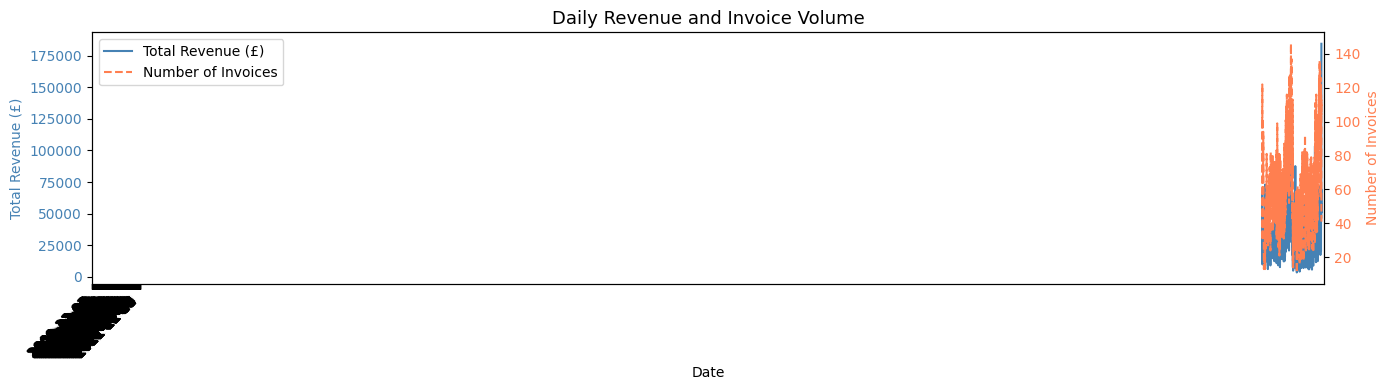

In [156]:
daily = invoice_df.groupby(invoice_df['InvoiceDate'].dt.date).agg(
    total_revenue = ('total_revenue', 'sum'),
    num_invoices  = ('Invoice', 'count')
).reset_index()

plot_revenue_invoices(daily, 'InvoiceDate',
                      'Daily Revenue and Invoice Volume',
                      'Date')

#### Weekly

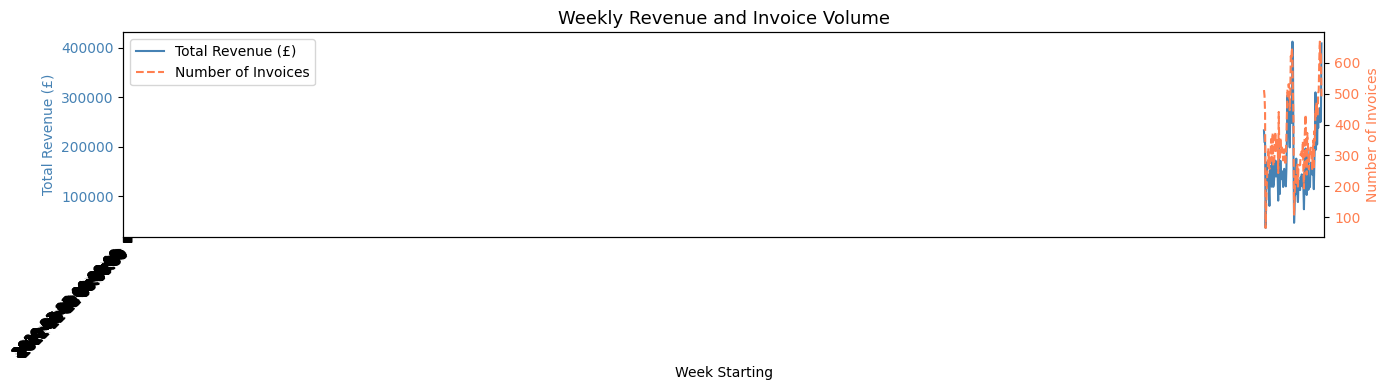

In [157]:
invoice_df['week'] = invoice_df['InvoiceDate'].dt.to_period('W').dt.start_time

weekly = invoice_df.groupby('week').agg(
    total_revenue = ('total_revenue', 'sum'),
    num_invoices  = ('Invoice', 'count')
).reset_index()

plot_revenue_invoices(weekly, 'week',
                      'Weekly Revenue and Invoice Volume',
                      'Week Starting')

#### Monthly

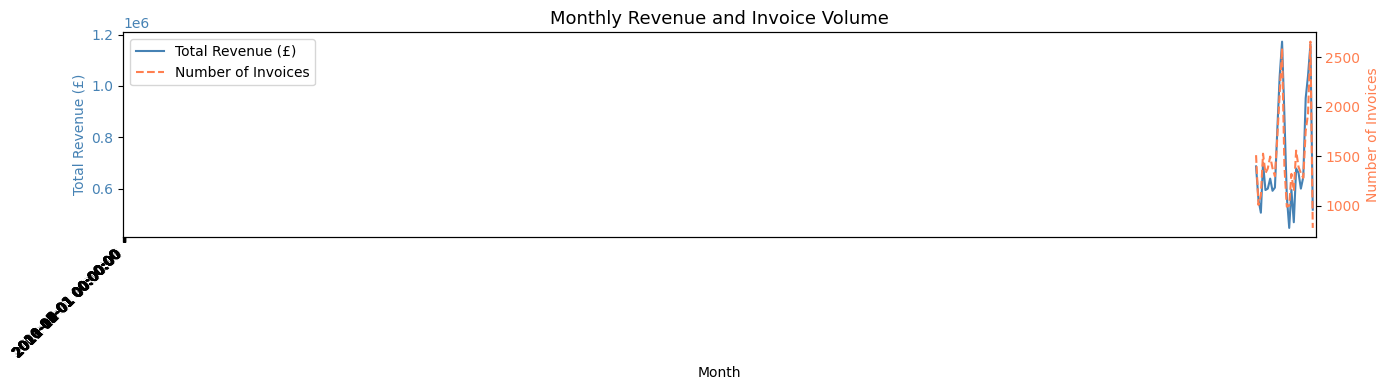

In [158]:
invoice_df['month'] = invoice_df['InvoiceDate'].dt.to_period('M').dt.start_time

monthly = invoice_df.groupby('month').agg(
    total_revenue = ('total_revenue', 'sum'),
    num_invoices  = ('Invoice', 'count')
).reset_index()

plot_revenue_invoices(monthly, 'month',
                      'Monthly Revenue and Invoice Volume',
                      'Month')

### Extracting datetime components as features

Beyond aggregations, we can extract components FROM the date itself.
These become features that capture cyclical business patterns:
   - Day of month:  are customers more likely to order at month start/end?
   - Weekday:       are orders concentrated on certain days?
   - Day of year:   seasonal position
   - Week of year:  useful for retail seasonality
   - Month:         strongest seasonal signal


In [159]:
invoice_df['day_of_month']  = invoice_df['InvoiceDate'].dt.day
invoice_df['weekday']       = invoice_df['InvoiceDate'].dt.dayofweek      # 0=Mon, 6=Sun
invoice_df['weekday_name']  = invoice_df['InvoiceDate'].dt.day_name()
invoice_df['day_of_year']   = invoice_df['InvoiceDate'].dt.dayofyear
invoice_df['week_of_year']  = invoice_df['InvoiceDate'].dt.isocalendar().week.astype(int)
invoice_df['month']         = invoice_df['InvoiceDate'].dt.month
invoice_df['hour']          = invoice_df['InvoiceDate'].dt.hour

invoice_df.head(5)

,Invoice,Customer ID,Country,InvoiceDate,total_quantity,total_revenue,num_items,week,month,day_of_month,weekday,weekday_name,day_of_year,week_of_year,hour
0,489434,13085,United Kingdom,2009-12-01 07:45:00,166,505.30,8,2009-11-30,12,1,1,Tuesday,335,49,7
1,489435,13085,United Kingdom,2009-12-01 07:46:00,60,145.80,4,2009-11-30,12,1,1,Tuesday,335,49,7
2,489436,13078,United Kingdom,2009-12-01 09:06:00,193,630.33,19,2009-11-30,12,1,1,Tuesday,335,49,9
3,489437,15362,United Kingdom,2009-12-01 09:08:00,145,310.75,23,2009-11-30,12,1,1,Tuesday,335,49,9
4,489438,18102,United Kingdom,2009-12-01 09:24:00,826,2286.24,17,2009-11-30,12,1,1,Tuesday,335,49,9


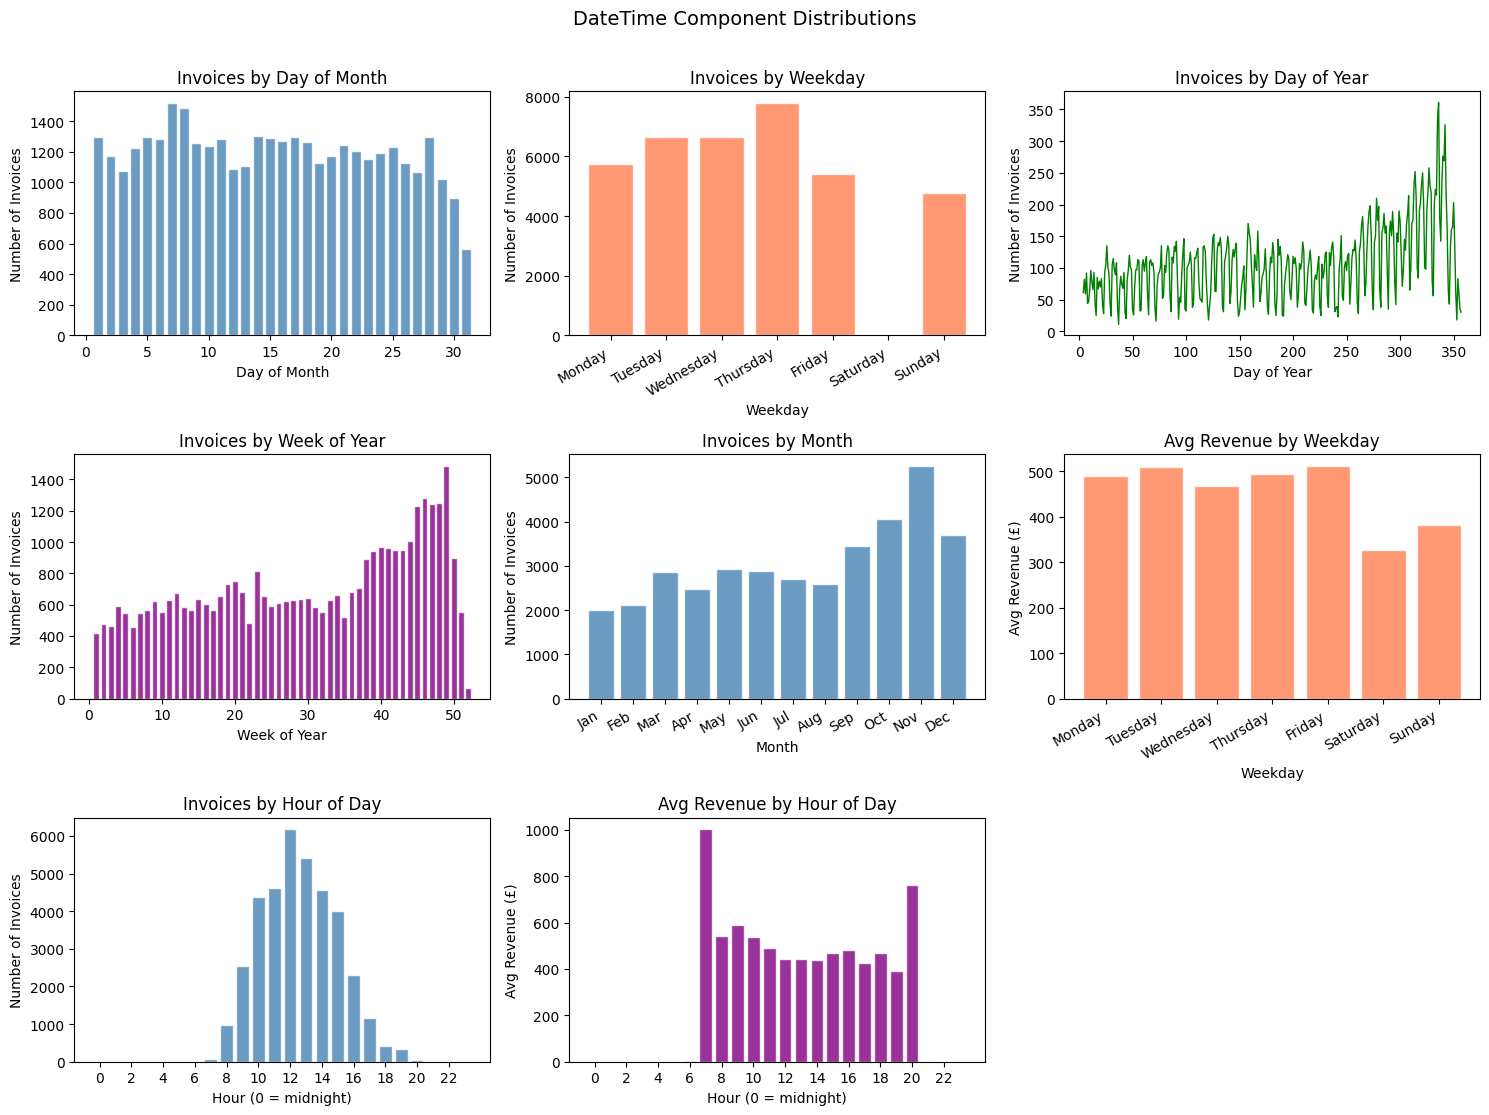

In [160]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))

# Day of month
axes[0,0].bar(range(1, 32),
              invoice_df.groupby('day_of_month')['Invoice'].count(),
              color='steelblue', edgecolor='white', alpha=0.8)
axes[0,0].set_title('Invoices by Day of Month', fontsize=12)
axes[0,0].set_xlabel('Day of Month')
axes[0,0].set_ylabel('Number of Invoices')

# Weekday
wd_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
wd_counts = invoice_df.groupby('weekday_name')['Invoice'].count().reindex(wd_order)
axes[0,1].bar(wd_order, wd_counts,
              color='coral', edgecolor='white', alpha=0.8)
axes[0,1].set_title('Invoices by Weekday', fontsize=12)
axes[0,1].set_xlabel('Weekday')
axes[0,1].set_ylabel('Number of Invoices')
plt.setp(axes[0,1].xaxis.get_majorticklabels(), rotation=30, ha='right')

# Day of year
axes[0,2].plot(invoice_df.groupby('day_of_year')['Invoice'].count(),
               color='green', linewidth=1)
axes[0,2].set_title('Invoices by Day of Year', fontsize=12)
axes[0,2].set_xlabel('Day of Year')
axes[0,2].set_ylabel('Number of Invoices')

# Week of year
axes[1,0].bar(invoice_df.groupby('week_of_year')['Invoice'].count().index,
              invoice_df.groupby('week_of_year')['Invoice'].count().values,
              color='purple', edgecolor='white', alpha=0.8)
axes[1,0].set_title('Invoices by Week of Year', fontsize=12)
axes[1,0].set_xlabel('Week of Year')
axes[1,0].set_ylabel('Number of Invoices')

# Month
axes[1,1].bar(range(1, 13),
              invoice_df.groupby('month')['Invoice'].count(),
              color='steelblue', edgecolor='white', alpha=0.8)
axes[1,1].set_title('Invoices by Month', fontsize=12)
axes[1,1].set_xlabel('Month')
axes[1,1].set_ylabel('Number of Invoices')
axes[1,1].set_xticks(range(1, 13))
axes[1,1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                            'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.setp(axes[1,1].xaxis.get_majorticklabels(), rotation=30, ha='right')

# Average revenue by weekday
wd_rev = invoice_df.groupby('weekday_name')['total_revenue'].mean().reindex(wd_order)
axes[1,2].bar(wd_order, wd_rev, color='coral', edgecolor='white', alpha=0.8)
axes[1,2].set_title('Avg Revenue by Weekday', fontsize=12)
axes[1,2].set_xlabel('Weekday')
axes[1,2].set_ylabel('Avg Revenue (£)')
plt.setp(axes[1,2].xaxis.get_majorticklabels(), rotation=30, ha='right')

# Copied this from below so that I could "Run all"
# Hour of day — reindex to all 24 hours so missing hours show as 0
hour_count = (invoice_df.groupby('hour')['Invoice'].count()
                        .reindex(range(24), fill_value=0))
hour_rev   = (invoice_df.groupby('hour')['total_revenue'].mean()
                        .reindex(range(24), fill_value=0))
# /copy section

# Hour of day — invoice count
axes[2,0].bar(range(24),
              hour_count, #replaced invoice_df.groupby('hour')['Invoice'].count()
              color='steelblue', edgecolor='white', alpha=0.8)
axes[2,0].set_title('Invoices by Hour of Day', fontsize=12)
axes[2,0].set_xlabel('Hour (0 = midnight)')
axes[2,0].set_ylabel('Number of Invoices')
axes[2,0].set_xticks(range(0, 24, 2))

# Hour of day — average revenue
axes[2,1].bar(range(24),
              hour_rev, #replaced invoice_df.groupby('hour')['total_revenue'].mean()
              color='purple', edgecolor='white', alpha=0.8)
axes[2,1].set_title('Avg Revenue by Hour of Day', fontsize=12)
axes[2,1].set_xlabel('Hour (0 = midnight)')
axes[2,1].set_ylabel('Avg Revenue (£)')
axes[2,1].set_xticks(range(0, 24, 2))

# Hide unused subplot
axes[2,2].set_visible(False)

plt.suptitle('DateTime Component Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


Not all 24 hours appear on the data! Let's fix it...

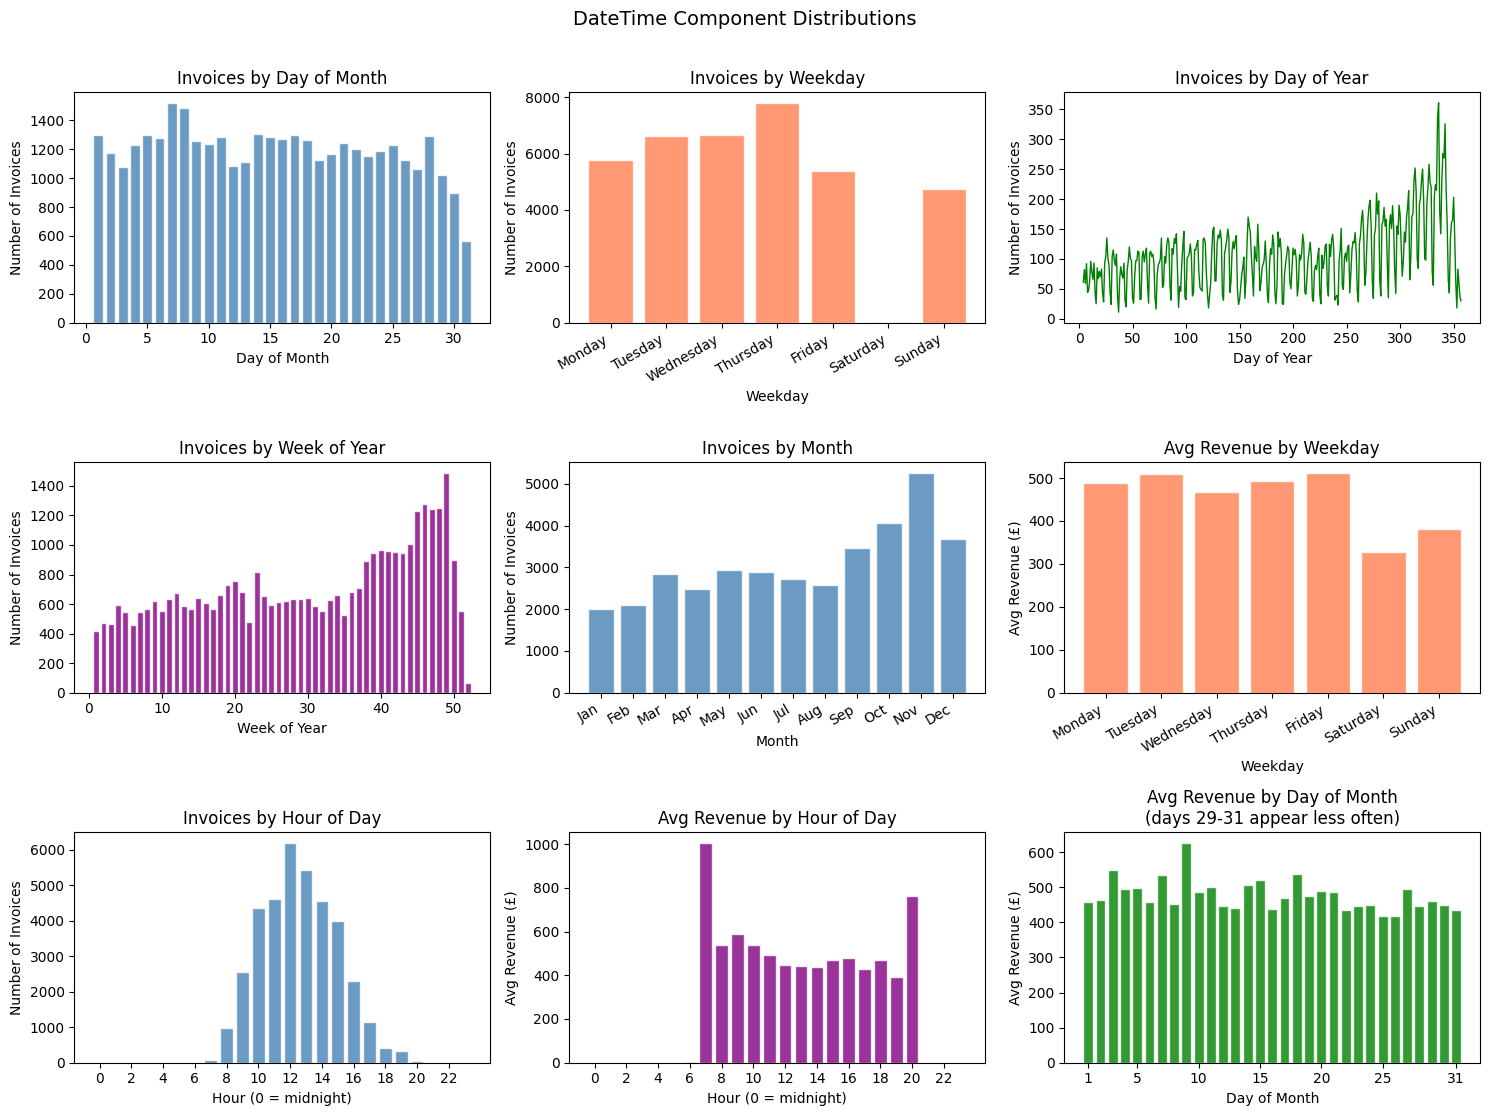

In [161]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))

# Day of month
axes[0,0].bar(range(1, 32),
              invoice_df.groupby('day_of_month')['Invoice'].count(),
              color='steelblue', edgecolor='white', alpha=0.8)
axes[0,0].set_title('Invoices by Day of Month', fontsize=12)
axes[0,0].set_xlabel('Day of Month')
axes[0,0].set_ylabel('Number of Invoices')

# Weekday
wd_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
wd_counts = invoice_df.groupby('weekday_name')['Invoice'].count().reindex(wd_order)
axes[0,1].bar(wd_order, wd_counts,
              color='coral', edgecolor='white', alpha=0.8)
axes[0,1].set_title('Invoices by Weekday', fontsize=12)
axes[0,1].set_xlabel('Weekday')
axes[0,1].set_ylabel('Number of Invoices')
plt.setp(axes[0,1].xaxis.get_majorticklabels(), rotation=30, ha='right')

# Day of year
axes[0,2].plot(invoice_df.groupby('day_of_year')['Invoice'].count(),
               color='green', linewidth=1)
axes[0,2].set_title('Invoices by Day of Year', fontsize=12)
axes[0,2].set_xlabel('Day of Year')
axes[0,2].set_ylabel('Number of Invoices')

# Week of year
axes[1,0].bar(invoice_df.groupby('week_of_year')['Invoice'].count().index,
              invoice_df.groupby('week_of_year')['Invoice'].count().values,
              color='purple', edgecolor='white', alpha=0.8)
axes[1,0].set_title('Invoices by Week of Year', fontsize=12)
axes[1,0].set_xlabel('Week of Year')
axes[1,0].set_ylabel('Number of Invoices')

# Month
axes[1,1].bar(range(1, 13),
              invoice_df.groupby('month')['Invoice'].count(),
              color='steelblue', edgecolor='white', alpha=0.8)
axes[1,1].set_title('Invoices by Month', fontsize=12)
axes[1,1].set_xlabel('Month')
axes[1,1].set_ylabel('Number of Invoices')
axes[1,1].set_xticks(range(1, 13))
axes[1,1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                            'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.setp(axes[1,1].xaxis.get_majorticklabels(), rotation=30, ha='right')

# Average revenue by weekday
wd_rev = invoice_df.groupby('weekday_name')['total_revenue'].mean().reindex(wd_order)
axes[1,2].bar(wd_order, wd_rev, color='coral', edgecolor='white', alpha=0.8)
axes[1,2].set_title('Avg Revenue by Weekday', fontsize=12)
axes[1,2].set_xlabel('Weekday')
axes[1,2].set_ylabel('Avg Revenue (£)')
plt.setp(axes[1,2].xaxis.get_majorticklabels(), rotation=30, ha='right')

# Hour of day — reindex to all 24 hours so missing hours show as 0
hour_count = (invoice_df.groupby('hour')['Invoice'].count()
                        .reindex(range(24), fill_value=0))
hour_rev   = (invoice_df.groupby('hour')['total_revenue'].mean()
                        .reindex(range(24), fill_value=0))

axes[2,0].bar(range(24), hour_count,
              color='steelblue', edgecolor='white', alpha=0.8)
axes[2,0].set_title('Invoices by Hour of Day', fontsize=12)
axes[2,0].set_xlabel('Hour (0 = midnight)')
axes[2,0].set_ylabel('Number of Invoices')
axes[2,0].set_xticks(range(0, 24, 2))

axes[2,1].bar(range(24), hour_rev,
              color='purple', edgecolor='white', alpha=0.8)
axes[2,1].set_title('Avg Revenue by Hour of Day', fontsize=12)
axes[2,1].set_xlabel('Hour (0 = midnight)')
axes[2,1].set_ylabel('Avg Revenue (£)')
axes[2,1].set_xticks(range(0, 24, 2))

# Avg revenue by day of month — reindex to all 31 days, fill missing with 0
dom_rev = (invoice_df.groupby('day_of_month')['total_revenue'].mean()
                     .reindex(range(1, 32), fill_value=0))

axes[2,2].bar(range(1, 32), dom_rev,
              color='green', edgecolor='white', alpha=0.8)
axes[2,2].set_title('Avg Revenue by Day of Month\n(days 29-31 appear less often)', fontsize=12)
axes[2,2].set_xlabel('Day of Month')
axes[2,2].set_ylabel('Avg Revenue (£)')
axes[2,2].set_xticks([1, 5, 10, 15, 20, 25, 31])

plt.suptitle('DateTime Component Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

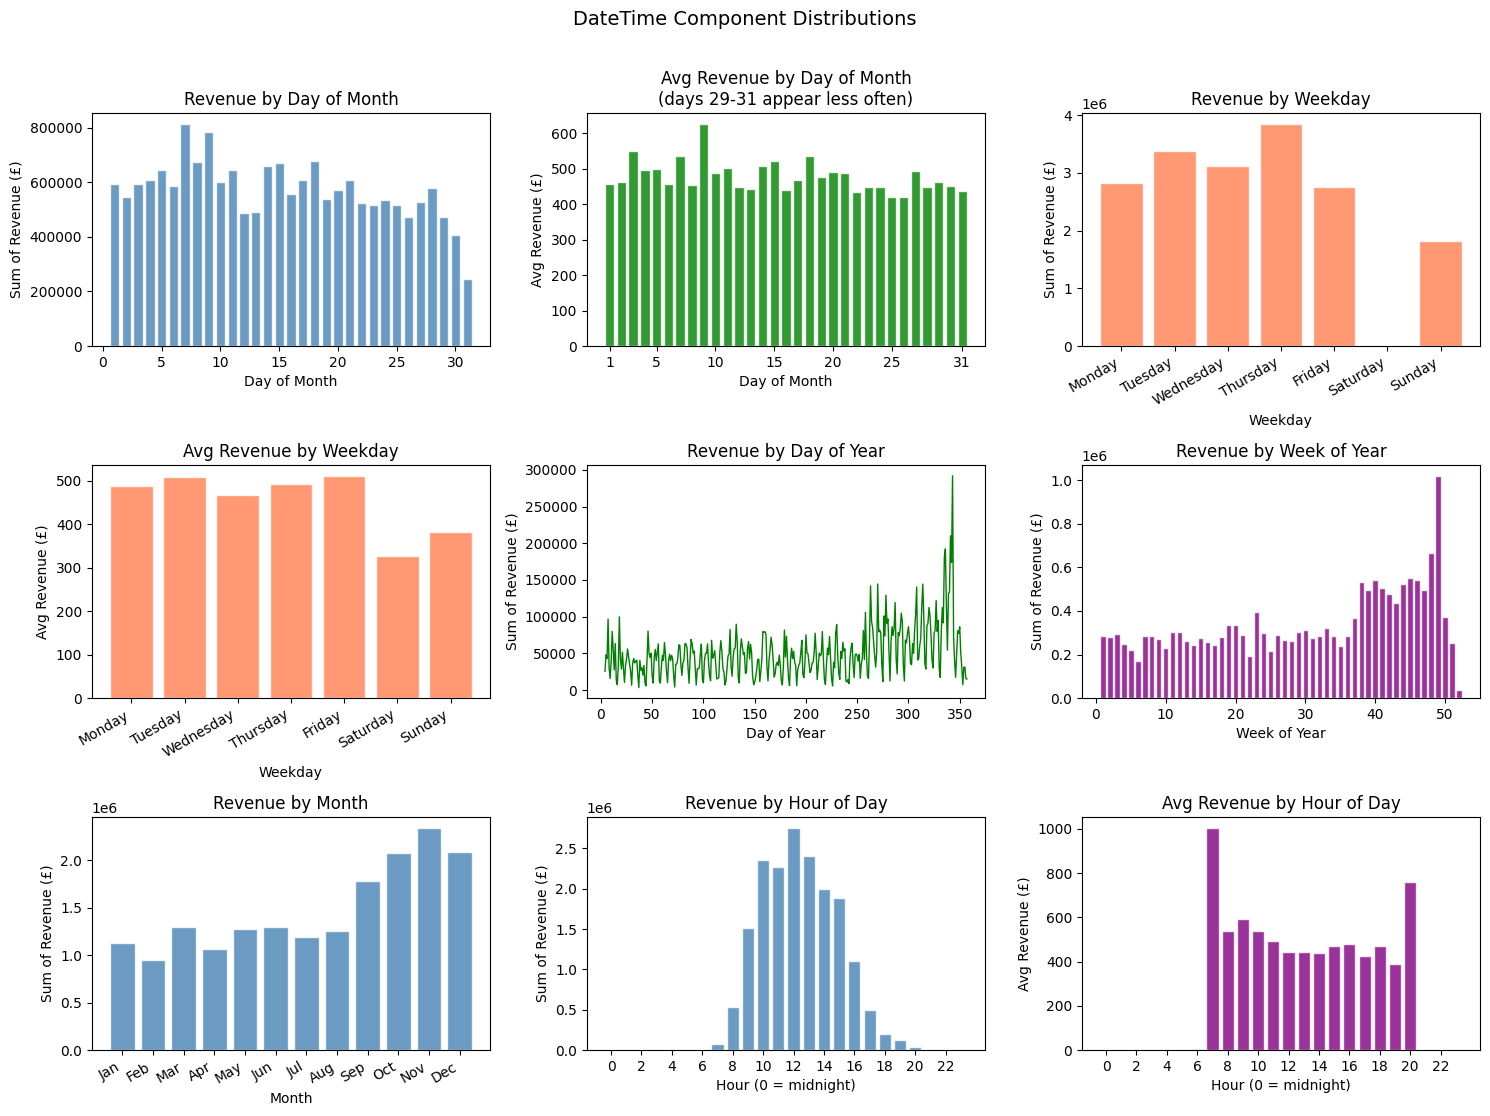

In [162]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))

# Day of month
axes[0,0].bar(range(1, 32),
              invoice_df.groupby('day_of_month')['total_revenue'].sum(),
              color='steelblue', edgecolor='white', alpha=0.8)
axes[0,0].set_title('Revenue by Day of Month', fontsize=12)
axes[0,0].set_xlabel('Day of Month')
axes[0,0].set_ylabel('Sum of Revenue (£)')

# Avg revenue by day of month — reindex to all 31 days, fill missing with 0
dom_rev = (invoice_df.groupby('day_of_month')['total_revenue'].mean()
                     .reindex(range(1, 32), fill_value=0))

axes[0,1].bar(range(1, 32), dom_rev,
              color='green', edgecolor='white', alpha=0.8)
axes[0,1].set_title('Avg Revenue by Day of Month\n(days 29-31 appear less often)', fontsize=12)
axes[0,1].set_xlabel('Day of Month')
axes[0,1].set_ylabel('Avg Revenue (£)')
axes[0,1].set_xticks([1, 5, 10, 15, 20, 25, 31])

# Weekday
wd_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
wd_counts = invoice_df.groupby('weekday_name')['total_revenue'].sum().reindex(wd_order)
axes[0,2].bar(wd_order, wd_counts,
              color='coral', edgecolor='white', alpha=0.8)
axes[0,2].set_title('Revenue by Weekday', fontsize=12)
axes[0,2].set_xlabel('Weekday')
axes[0,2].set_ylabel('Sum of Revenue (£)')
plt.setp(axes[0,2].xaxis.get_majorticklabels(), rotation=30, ha='right')

# Average revenue by weekday
wd_rev = invoice_df.groupby('weekday_name')['total_revenue'].mean().reindex(wd_order)
axes[1,0].bar(wd_order, wd_rev, color='coral', edgecolor='white', alpha=0.8)
axes[1,0].set_title('Avg Revenue by Weekday', fontsize=12)
axes[1,0].set_xlabel('Weekday')
axes[1,0].set_ylabel('Avg Revenue (£)')
plt.setp(axes[1,0].xaxis.get_majorticklabels(), rotation=30, ha='right')

# Day of year
axes[1,1].plot(invoice_df.groupby('day_of_year')['total_revenue'].sum(),
               color='green', linewidth=1)
axes[1,1].set_title('Revenue by Day of Year', fontsize=12)
axes[1,1].set_xlabel('Day of Year')
axes[1,1].set_ylabel('Sum of Revenue (£)')

# Week of year
axes[1,2].bar(invoice_df.groupby('week_of_year')['total_revenue'].sum().index,
              invoice_df.groupby('week_of_year')['total_revenue'].sum().values,
              color='purple', edgecolor='white', alpha=0.8)
axes[1,2].set_title('Revenue by Week of Year', fontsize=12)
axes[1,2].set_xlabel('Week of Year')
axes[1,2].set_ylabel('Sum of Revenue (£)')

# Month
axes[2,0].bar(range(1, 13),
              invoice_df.groupby('month')['total_revenue'].sum(),
              color='steelblue', edgecolor='white', alpha=0.8)
axes[2,0].set_title('Revenue by Month', fontsize=12)
axes[2,0].set_xlabel('Month')
axes[2,0].set_ylabel('Sum of Revenue (£)')
axes[2,0].set_xticks(range(1, 13))
axes[2,0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                            'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.setp(axes[2,0].xaxis.get_majorticklabels(), rotation=30, ha='right')



# Hour of day — reindex to all 24 hours so missing hours show as 0
hour_count = (invoice_df.groupby('hour')['total_revenue'].sum()
                        .reindex(range(24), fill_value=0))
hour_rev   = (invoice_df.groupby('hour')['total_revenue'].mean()
                        .reindex(range(24), fill_value=0))

axes[2,1].bar(range(24), hour_count,
              color='steelblue', edgecolor='white', alpha=0.8)
axes[2,1].set_title('Revenue by Hour of Day', fontsize=12)
axes[2,1].set_xlabel('Hour (0 = midnight)')
axes[2,1].set_ylabel('Sum of Revenue (£)')
axes[2,1].set_xticks(range(0, 24, 2))

axes[2,2].bar(range(24), hour_rev,
              color='purple', edgecolor='white', alpha=0.8)
axes[2,2].set_title('Avg Revenue by Hour of Day', fontsize=12)
axes[2,2].set_xlabel('Hour (0 = midnight)')
axes[2,2].set_ylabel('Avg Revenue (£)')
axes[2,2].set_xticks(range(0, 24, 2))



plt.suptitle('DateTime Component Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Our Question:
- **What customers did not buy anything in the last month worth of data?**
- **Can we predict it?**

In [163]:
invoice_df['year_month']    = invoice_df['InvoiceDate'].dt.to_period('M')
invoice_df.groupby('year_month').count()

,Invoice,Customer ID,Country,InvoiceDate,total_quantity,total_revenue,num_items,week,month,day_of_month,weekday,weekday_name,day_of_year,week_of_year,hour
year_month,,,,,,,,,,,,,,,
2009-12,1513,1513,1513,1513,1513,1513,1513,1513,1513,1513,1513,1513,1513,1513,1513
2010-01,1011,1011,1011,1011,1011,1011,1011,1011,1011,1011,1011,1011,1011,1011,1011
2010-02,1106,1106,1106,1106,1106,1106,1106,1106,1106,1106,1106,1106,1106,1106,1106
2010-03,1528,1528,1528,1528,1528,1528,1528,1528,1528,1528,1528,1528,1528,1528,1528
2010-04,1331,1331,1331,1331,1331,1331,1331,1331,1331,1331,1331,1331,1331,1331,1331
2010-05,1378,1378,1378,1378,1378,1378,1378,1378,1378,1378,1378,1378,1378,1378,1378
2010-06,1499,1499,1499,1499,1499,1499,1499,1499,1499,1499,1499,1499,1499,1499,1499
2010-07,1382,1382,1382,1382,1382,1382,1382,1382,1382,1382,1382,1382,1382,1382,1382
2010-08,1300,1300,1300,1300,1300,1300,1300,1300,1300,1300,1300,1300,1300,1300,1300


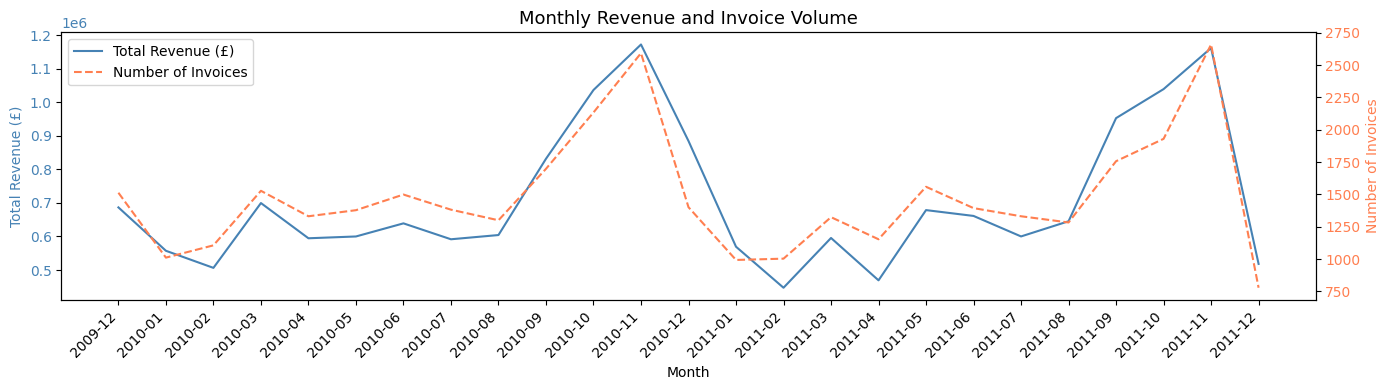

In [164]:
monthly = invoice_df.groupby('year_month').agg(
    total_revenue = ('total_revenue', 'sum'),
    num_invoices   = ('Invoice', 'count')
).reset_index()

monthly['year_month'] = monthly['year_month'].astype(str)
plot_revenue_invoices(monthly, 'year_month',
                      'Monthly Revenue and Invoice Volume',
                      'Month')

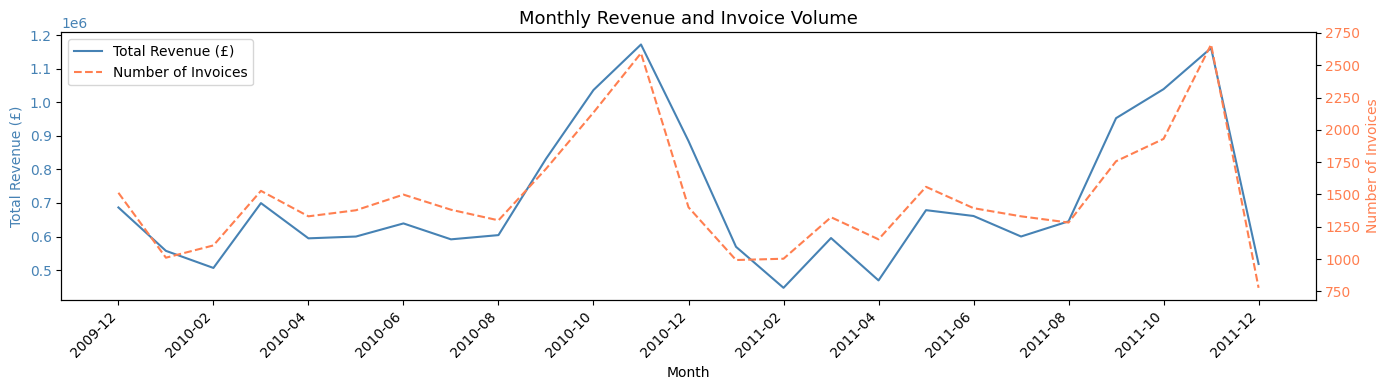

In [165]:
monthly = invoice_df.groupby('year_month').agg(
    total_revenue = ('total_revenue', 'sum'),
    num_invoices  = ('Invoice', 'count')
).reset_index()

monthly['year_month'] = monthly['year_month'].astype('str')
plot_revenue_invoices(monthly, 'year_month',
                      'Monthly Revenue and Invoice Volume',
                      'Month', skip =True)


In [166]:
invoice_df = invoice_df[invoice_df.year_month != '2011-12']

In [167]:
invoice_df['train_test_flag'] = np.where(
    invoice_df['year_month'] == '2011-11',
    'test',
    'train'
)
invoice_df

/tmp/ipykernel_4776/2286268358.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  invoice_df['train_test_flag'] = np.where(


,Invoice,Customer ID,Country,InvoiceDate,total_quantity,total_revenue,num_items,week,month,day_of_month,weekday,weekday_name,day_of_year,week_of_year,hour,year_month,train_test_flag
0,489434,13085,United Kingdom,2009-12-01 07:45:00,166,505.30,8,2009-11-30,12,1,1,Tuesday,335,49,7,2009-12,train
1,489435,13085,United Kingdom,2009-12-01 07:46:00,60,145.80,4,2009-11-30,12,1,1,Tuesday,335,49,7,2009-12,train
2,489436,13078,United Kingdom,2009-12-01 09:06:00,193,630.33,19,2009-11-30,12,1,1,Tuesday,335,49,9,2009-12,train
3,489437,15362,United Kingdom,2009-12-01 09:08:00,145,310.75,23,2009-11-30,12,1,1,Tuesday,335,49,9,2009-12,train
4,489438,18102,United Kingdom,2009-12-01 09:24:00,826,2286.24,17,2009-11-30,12,1,1,Tuesday,335,49,9,2009-12,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36256,579868,15544,United Kingdom,2011-11-30 16:43:00,406,328.32,22,2011-11-28,11,30,2,Wednesday,334,48,16,2011-11,test
36257,579870,12437,France,2011-11-30 16:47:00,99,292.41,14,2011-11-28,11,30,2,Wednesday,334,48,16,2011-11,test
36258,579872,14085,United Kingdom,2011-11-30 16:54:00,239,278.82,17,2011-11-28,11,30,2,Wednesday,334,48,16,2011-11,test
36259,579881,12429,Denmark,2011-11-30 17:22:00,512,905.52,27,2011-11-28,11,30,2,Wednesday,334,48,17,2011-11,test


### How do we do it??!


### Create our churn labels

1 - OK, this was my initial thought:
The instructions weren't entirely clear to me as to the definition of churn. I have defined it as someone not making a purchase in the month following a month with a purchase. This was a bit hard to code up but I think that I have it.

In a real business situation I'd interrogate the business extensively to make sure that I understood the desired logic. In my experience this is a great discovery method where we end up both learning about how the data actually works and then come to a mutual understanding of where we're trying to go. In other words a lot of time the folks running the business don't understand exactly how the data works at the granular level. For this exercise it doesn't matter as long as I'm clear on my assumptions.

2 - BUT I didn't like what I came up with when I in #1 so I changed the logic and took some liberty with the instructions. I think what we're really trying to do is predict churn using the current (and perhaps previous) month's data. So, for any given month we need to know if the customer churns next month, not this month. We want to align our signal with our results. So I redefined the churn to indicate next month's activity. If a customer makes a purchase in month x but not in x+1 then month x gets churn = 1. Why? Because we will be using month x's data when x is the current month to predict churn for x + 1 (next month).

I suspect in a real business case that they would define churn a bit less strictly - more like "A customer that has not made a purchase in three months". They would also have more specific guidance on what defines a customer.

### Missing row explanation
Because I implemented the logic (#2) immediately above, there is no need to create missing records. The missing or "churn" signal is captured in the churn label. When I implemented #1 I had included dummy records as that was the best way to capture the absense of purchases (churn).

In [168]:
# Let's create our churn labels
# JSP 20260414

# Build labels_df from invoice_df
# Each row = one active customer-month
# Label = did they churn the FOLLOWING month (no purchase next month = 1)

# Get one row per customer per month where they were active
active = invoice_df.groupby(['Customer ID', 'year_month']).agg(
    total_revenue=('total_revenue', 'sum')
).reset_index()

# Build set of active (customer, month) pairs for fast lookup
active_set = set(zip(active['Customer ID'], active['year_month']))

# For each active row, check if the customer was active the next month
all_months = sorted(active['year_month'].unique())

def churned_next_month(row):
    month_idx = all_months.index(row['year_month'])
    if month_idx + 1 < len(all_months):
        next_month = all_months[month_idx + 1]
        return 0 if (row['Customer ID'], next_month) in active_set else 1
    return np.nan  # no next month available (Nov 2011)

active['churned'] = active.apply(churned_next_month, axis=1)

# Split train/test
# Train: everything before Oct 2011 (has labels)
# Test: Oct 2011 (label = did they show up in Nov 2011)
# Nov 2011 rows have no label (no Dec data) — drop them
labels_df = active.dropna(subset=['churned']).copy()
labels_df['churned'] = labels_df['churned'].astype(int)

train_df = labels_df[labels_df['year_month'] < '2011-10']
test_df = labels_df[labels_df['year_month'] == '2011-10']

print(f"Train rows: {len(train_df):,}")
print(f"Test rows:  {len(test_df):,}")
print(f"Train churn rate: {train_df['churned'].mean():.1%}")
print(f"Test churn rate:  {test_df['churned'].mean():.1%}")

labels_df

Train rows: 21,954
Test rows:  1,364
Train churn rate: 61.8%
Test churn rate:  54.4%


,Customer ID,year_month,total_revenue,churned
0,12346,2009-12,113.50,0
1,12346,2010-01,90.00,1
2,12346,2010-03,27.05,1
3,12346,2010-06,142.31,1
4,12346,2011-01,77183.60,1
...,...,...,...,...
24978,18287,2010-05,1071.61,1
24979,18287,2010-09,892.60,1
24980,18287,2010-11,381.50,1
24981,18287,2011-05,765.28,1


### Split into test and train sets
This is where I really took liberty with the instructions. Becuase we're labeling using facts from month x + 1 we need our last month of data to be used to label. That meanse 2011-10 become our test set with 2011-11 being our labels for it. 2011-11 data isn't used. I believe this to be better than what is proposed in the instructions but happy to take my lumps on the grade if the professor disagrees.

Great project!

In [169]:
# JSP 20260414
# Split train/test
# Train: everything before Oct 2011 (has labels)
# Test: Oct 2011 (label = did they show up in Nov 2011)
# Nov 2011 rows have no label (no Dec data) — drop them
labels_df = active.dropna(subset=['churned']).copy()
labels_df['churned'] = labels_df['churned'].astype(int)

train_df = labels_df[labels_df['year_month'] < '2011-10']
test_df = labels_df[labels_df['year_month'] == '2011-10']

print(f"Train rows: {len(train_df):,}")
print(f"Test rows:  {len(test_df):,}")
print(f"Train churn rate: {train_df['churned'].mean():.1%}")
print(f"Test churn rate:  {test_df['churned'].mean():.1%}")

Train rows: 21,954
Test rows:  1,364
Train churn rate: 61.8%
Test churn rate:  54.4%
